In [2]:
!pip install -q -U scikit-learn pandas ipywidgets

In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras
from keras import layers

import numpy as np
import random

import matplotlib.pyplot as plt
from tqdm import tqdm


# ANSI codes
BOLD     = "\033[1m"
RED      = "\033[31m"
GREEN    = "\033[32m"
RESET    = "\033[0m"


In [4]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X.reshape(-1, 28, 28)  # optional: reshape from (70000, 784) to (70000, 28, 28)

# Split if needed
X_train, y_train = X[:60000], y[:60000]
X_test, y_test = X[60000:], y[60000:]

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)


X_train = (X_train - 128)/128

X_test = (X_test - 128)/128

X_train.min(),X_train.max()

(np.float64(-1.0), np.float64(0.9921875))

In [5]:
model = keras.Sequential([
    # Encoder
    layers.Dense(500, activation='relu'),
    layers.Dense(100,activation='relu'),

    # Decoder
    layers.Dense(100, activation='relu'),
    layers.Dense(500,activation='relu'),
    layers.Dense(X_train.shape[1])]
)

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='mse', metrics=["accuracy"])
model.fit(X_train, X_train, batch_size=1000, epochs=20)
model.fit(X_train, X_train, batch_size=3000, epochs=10)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.0059 - loss: 0.4053
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0115 - loss: 0.1401
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0108 - loss: 0.1026
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0113 - loss: 0.0875
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0109 - loss: 0.0797
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0121 - loss: 0.0722
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0131 - loss: 0.0681
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0128 - loss: 0.0649
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0125 - loss: 0.0632
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0132 - loss: 0.0616
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0131 - loss: 0.0614
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0140 - l

2025-06-25 02:04:45.324283: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


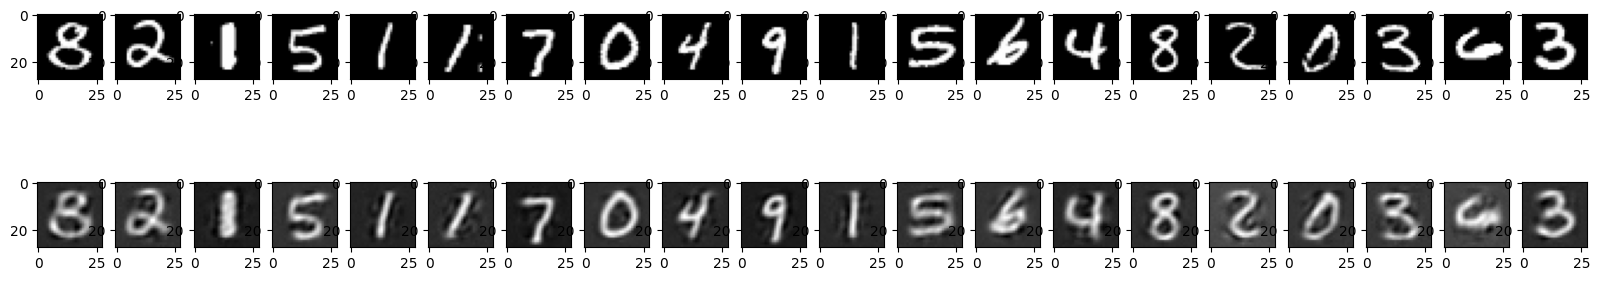

In [8]:
random20  = [random.randint(0,X_test.shape[0]) for _ in range(20)]

xtest = X_test[random20]
ytest = model(xtest)


plt.figure(figsize=(20,4))
for i in range(20):
    plt.subplot(2,20,1+i)
    plt.imshow(xtest[i].reshape(28,28), cmap='gray')

    plt.subplot(2,20,21+i)
    plt.imshow(ytest[i].reshape(28,28), cmap='gray')

Reconstruction Error : 3.23%


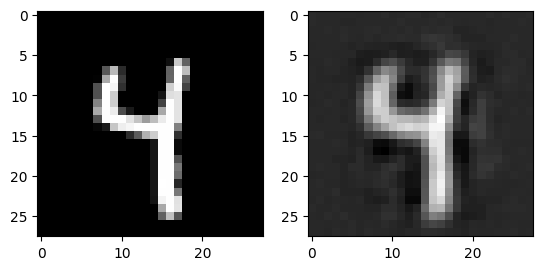

In [9]:
random_id = random.randint(0,X_test.shape[0])

x = X_test[random_id: random_id+1]
y = model(x)

loss = np.mean((x-y)**2)

plt.subplot(1,2,1)
plt.imshow(x.reshape(28,28), cmap='gray')

plt.subplot(1,2,2)
plt.imshow(y.reshape(28,28), cmap='gray')

print(f"Reconstruction Error : {BOLD}{GREEN}{loss*100:.2f}%")

Reconstruction Error : 7.29%


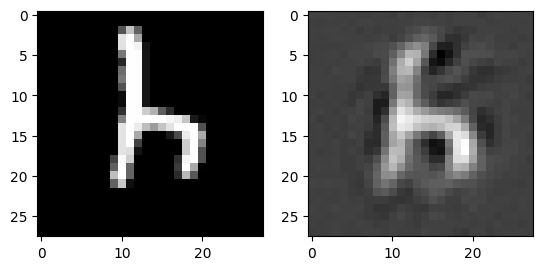

In [10]:
xf = x[:,::-1]
yf = model(xf)

loss = np.mean((xf-yf)**2)

plt.subplot(1,2,1)
plt.imshow(xf.reshape(28,28), cmap='gray')

plt.subplot(1,2,2)
plt.imshow(yf.reshape(28,28), cmap='gray')

print(f"Reconstruction Error : {BOLD}{RED}{loss*100:.2f}%")

In [ ]:
# COMMENTS

# 1. Reconstruction Error is higher when Flipped/Rotated

# We can detect anomaly by looking at the how many standard deviations away is the reconstruction error of an input and then use a suitable threshold to mark as anomalous if beyond that threshold